In [8]:
import sys
sys.path.append('../')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from models.model import STGAT
from train import prepare_data

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')

In [9]:
# Load the data
X_train, Y_train, X_test, Y_test, num_nodes, num_features = prepare_data('../processed/final_stgat_input.csv', seq_len=12)

# Load the graph edges
adj_matrix = np.load('../processed/adjacency_matrix.npy')
edges = np.argwhere(adj_matrix == 1)
edge_index = torch.tensor(edges.T, dtype=torch.long)

# Initialize the model and load the trained weights
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = STGAT(in_channels=num_features, hidden_channels=64, out_channels=1, num_nodes=num_nodes).to(device)
model.load_state_dict(torch.load('../models/stgat_weights.pth', weights_only=True))
model.eval() # turns off gradients
edge_index = edge_index.to(device)

print("\nModel and Data successfully loaded!")

Loading processed data...
Detected 263 zones and 5 weather features.
Creating sequential windows...
Executing chronological split (2024 Train / 2025 Test)...

Model and Data successfully loaded!


In [10]:
# Convert test truth to numpy
Y_test_numpy = np.array(Y_test, dtype=np.float32)

# Run the ST-GAT predictions in batches
batch_size = 32
stgat_predictions = []

with torch.no_grad():
    for i in range(0, len(X_test), batch_size):
        # Grab a small chunk of data and move it to the GPU
        batch_X = torch.tensor(X_test[i:i+batch_size], dtype=torch.float32).to(device)
        
        # Predict and move the answer immediately back to CPU memory
        batch_pred = model(batch_X, edge_index).cpu().numpy()
        stgat_predictions.append(batch_pred)

# Concatenate all batch predictions into a single array
stgat_predictions = np.concatenate(stgat_predictions, axis=0)

# Baseline: Naive prediction using the last observed value
# X_test shape is (samples, seq_len, nodes, features). Demand is feature 0.
baseline_predictions = X_test[:, -1, :, 0:1] 

# Calculate Metrics (MSE and MAE)
def calculate_metrics(pred, truth):
    mse = np.mean((pred - truth)**2)
    mae = np.mean(np.abs(pred - truth))
    return mse, mae

stgat_mse, stgat_mae = calculate_metrics(stgat_predictions, Y_test_numpy)
base_mse, base_mae = calculate_metrics(baseline_predictions, Y_test_numpy)

print(f"--- MEAN SQUARED ERROR (MSE) ---")
print(f"Naive Baseline: {base_mse:.4f}")
print(f"ST-GAT Model:   {stgat_mse:.4f}")

print(f"\n--- MEAN ABSOLUTE ERROR (MAE) ---")
print(f"Naive Baseline: {base_mae:.4f}")
print(f"ST-GAT Model:   {stgat_mae:.4f}")

--- MEAN SQUARED ERROR (MSE) ---
Naive Baseline: 0.4850
ST-GAT Model:   0.3236

--- MEAN ABSOLUTE ERROR (MAE) ---
Naive Baseline: 0.4590
ST-GAT Model:   0.3882


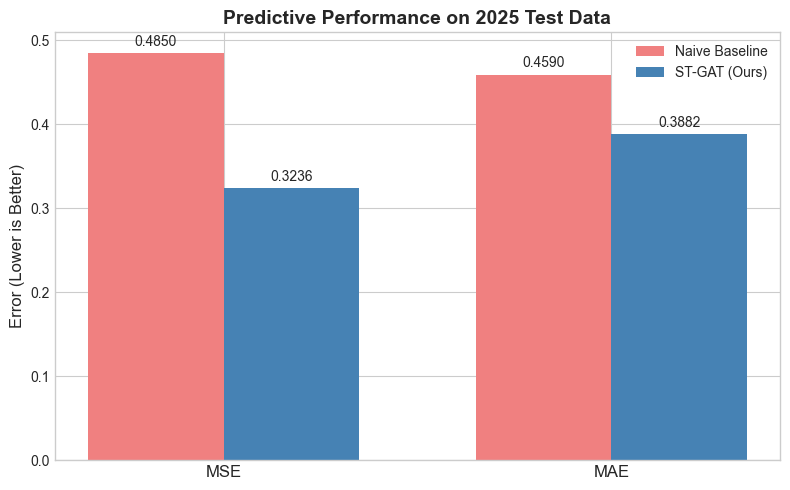

In [11]:
metrics = ['MSE', 'MAE']
baseline_scores = [base_mse, base_mae]
stgat_scores = [stgat_mse, stgat_mae]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, baseline_scores, width, label='Naive Baseline', color='lightcoral')
rects2 = ax.bar(x + width/2, stgat_scores, width, label='ST-GAT (Ours)', color='steelblue')

ax.set_ylabel('Error (Lower is Better)', fontsize=12)
ax.set_title('Predictive Performance on 2025 Test Data', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend()

for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=300)
plt.show()

Running Permutation Feature Importance...


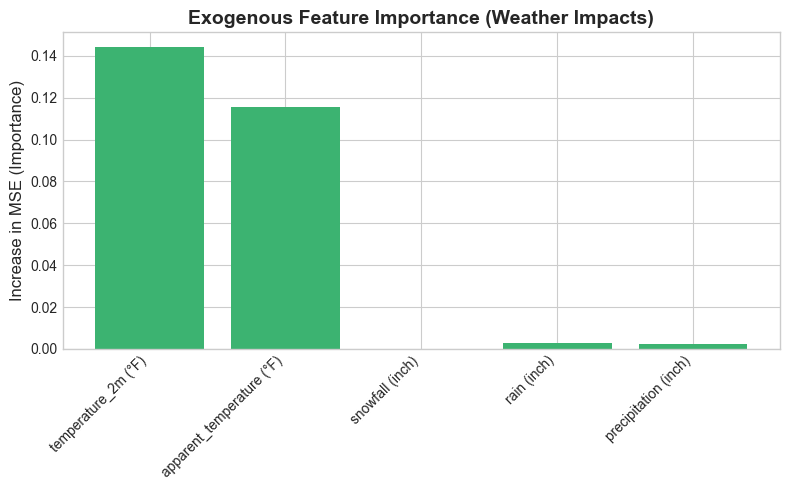

In [14]:
# Permutation Feature Importance
print("Running Permutation Feature Importance...")
feature_names = ['Past Demand', 'Temperature', 'Precipitation', 'Rain', 'Snow']
importance_scores = []

# Base MSE without any scrambling
base_mse, _ = calculate_metrics(stgat_predictions, Y_test_numpy)

for feature_idx in range(num_features):
    # Create a copy of the test data
    X_scrambled = X_test.copy()
    
    # Shuffle only the specific feature across the entire dataset
    np.random.shuffle(X_scrambled[:, :, :, feature_idx])
    
    # Run predictions on the scrambled data
    scrambled_preds = []
    with torch.no_grad():
        for i in range(0, len(X_scrambled), batch_size):
            batch_X = torch.tensor(X_scrambled[i:i+batch_size], dtype=torch.float32).to(device)
            batch_pred = model(batch_X, edge_index).cpu().numpy()
            scrambled_preds.append(batch_pred)
            
    scrambled_preds = np.concatenate(scrambled_preds, axis=0)
    
    # Calculate how much the error increased
    scrambled_mse, _ = calculate_metrics(scrambled_preds, Y_test_numpy)
    importance = scrambled_mse - base_mse
    importance_scores.append(importance)

df_temp = pd.read_csv('../processed/final_stgat_input.csv', index_col=0, nrows=0)
weather_cols = [c for c in df_temp.columns if not c.isdigit()]
feature_names = ['Past Demand'] + weather_cols

fig, ax = plt.subplots(figsize=(8, 5))

weather_features = feature_names[1:]
weather_importances = importance_scores[1:]

ax.bar(weather_features, weather_importances, color='mediumseagreen')
ax.set_ylabel('Increase in MSE (Importance)', fontsize=12)
ax.set_title('Exogenous Feature Importance (Weather Impacts)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()